# Load Data

In [13]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

file_path = "/Users/kyle/stock-trading-analytics-/data/spy_5y.csv"
df_csv = pd.read_csv(file_path)


# Transform Data

In [14]:
df_csv = df_csv.drop([0]).reset_index(drop=True)
df_csv = df_csv.rename(columns={'Price': 'Date'})
column_order = ['Date', 'Open', 'Close', 'High', 'Low', 'Volume']
df_reordered = df_csv[column_order].copy()
df_reordered.dropna(inplace=True) 
df = df_reordered
df = df_csv[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']].copy()

df['Open'] = pd.to_numeric(df_csv['Open'], errors='coerce')
df['Low'] = pd.to_numeric(df_csv['Low'], errors='coerce')
df['High'] = pd.to_numeric(df_csv['High'], errors='coerce')
df['Volume'] = pd.to_numeric(df_csv['Volume'], errors='coerce')
df['Close'] = pd.to_numeric(df_csv['Close'], errors='coerce')

# Explore Data

<Axes: title={'center': 'SPY Daily Returns'}>

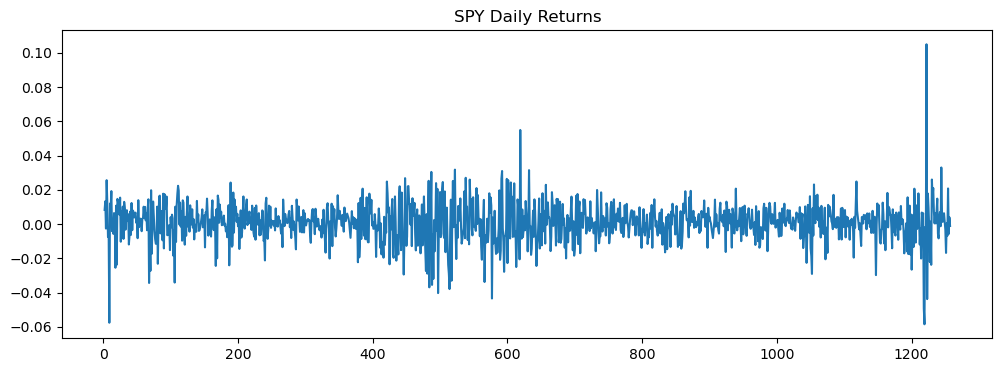

In [15]:
# Daily Returns
df['Daily Return'] = df['Close'].pct_change()
df['Daily Return'].plot(figsize=(12, 4), title='SPY Daily Returns')

<Axes: title={'center': 'SPY Trading Volume'}>

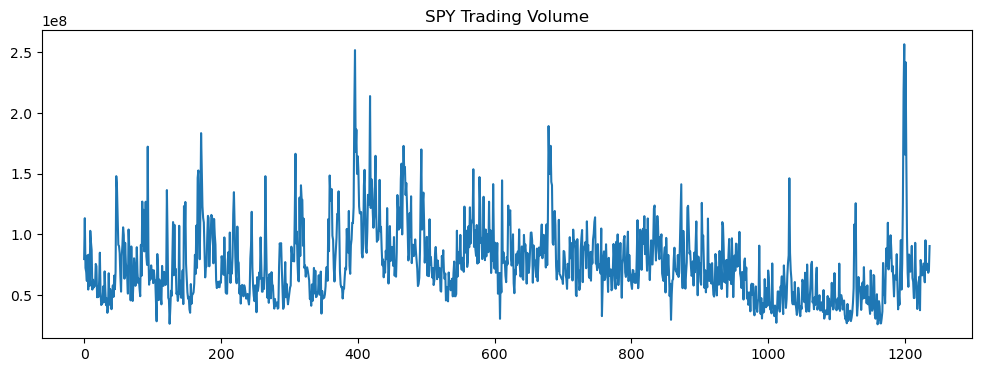

In [33]:
# Volume
df['Volume'].plot(figsize=(12, 4), title='SPY Trading Volume')

<Axes: title={'center': '21-Day Rolling Volatility'}>

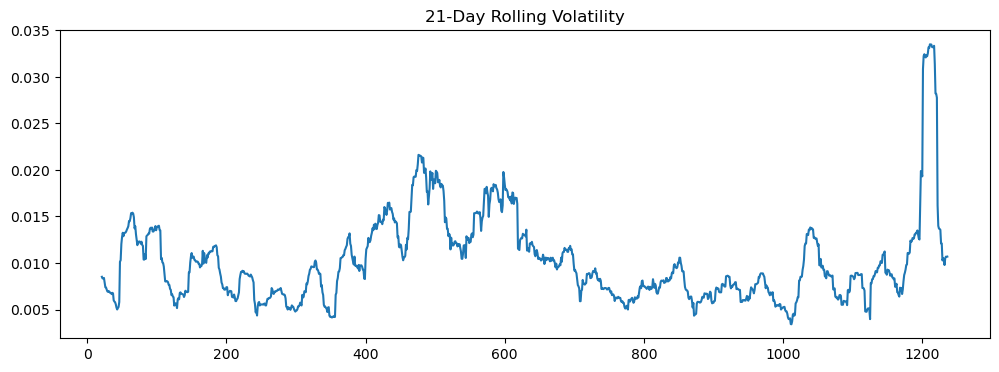

In [34]:
# Rolling Volatility (21-day std dev)
df['Rolling Volatility'] = df['Daily Return'].rolling(window=21).std()
df['Rolling Volatility'].plot(figsize=(12, 4), title='21-Day Rolling Volatility')

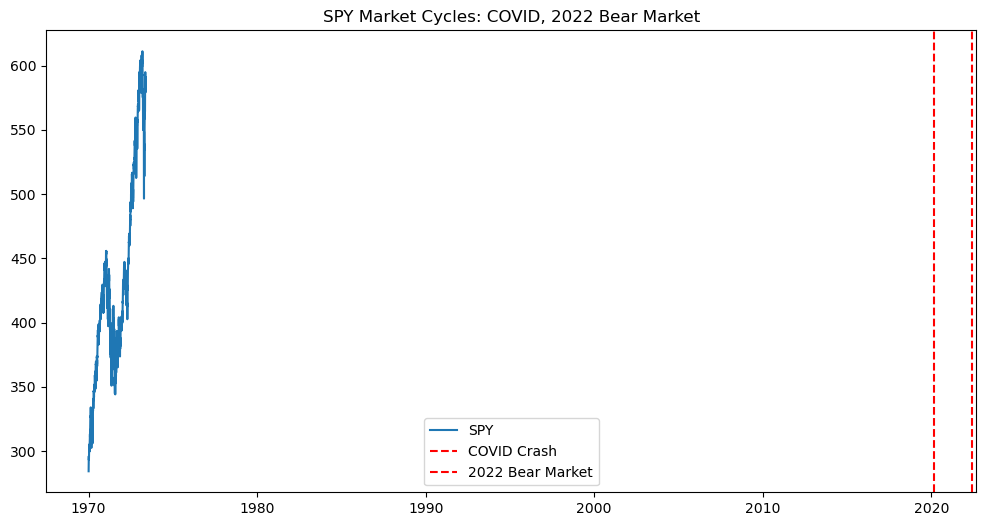

In [37]:
events = {
    'COVID Crash': '2020-03-01',
    '2022 Bear Market': '2022-06-01'
}

plt.figure(figsize=(12, 6))
plt.plot(df['Close'], label='SPY')
for name, date in events.items():
    plt.axvline(pd.to_datetime(date), color='red', linestyle='--', label=name)
plt.legend()
plt.title('SPY Market Cycles: COVID, 2022 Bear Market')
plt.show()